
# Importações

In [55]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from shap.plots import colors

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

MODELOS = ["MLP", "RF", "XGBoost"]
SEEDS = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
HORIZONTES = [3, 6, 12]
OTIMIZADORES = ["PSO", "SA"]
N_CLASSES = [3, 4, 5, 6, 7, 8, 9, 10]
N_ITER = 15
N_SOLUCOES = 15
SEED = 100


def reset_seed(rnd_seed=SEED):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)


warnings.filterwarnings("ignore")
reset_seed()

## Melhores Features

In [56]:
df_features = pd.read_csv("./resultados/features/fitness_features_regressao.csv", sep=";", decimal=".")

df_features = df_features.sort_values("RRMSE").head(1).reset_index(drop=True)
df_features = pd.DataFrame(
    columns=str(df_features.iloc[0]["FEATURES"]).replace("(", '').replace(")", '').replace("'", "").split(", "))

df_features = df_features.columns

df_features

Index(['TEMP_MÉD_MIN_MENS', 'TEMP_MÉD_MÉD_MENS', 'PRECIPITAÇÃO_MÉD_MENS',
       'TEMP_MIN_MAX_MENS', 'TEMP_MAX_MIN_MENS', 'PRECIPITAÇÃO_MIN_MENS',
       'TEMP_MAX_MAX_MENS', 'DIA_DA_SEMANA_dom', 'DIA_DA_SEMANA_seg',
       'DIA_DA_SEMANA_sáb', 'DIA_DA_SEMANA_ter', 'MÊS_abr', 'MÊS_ago',
       'MÊS_fev', 'MÊS_jun', 'MÊS_mai', 'MÊS_nov', 'ANO_2021', 'ANO_2022',
       'ANO_2023', 'ANO_2015', 'ANO_2016', 'ANO_2017', 'ANO_2018', 'ANO_2019',
       'CAMPUS_ASTORGA', 'CAMPUS_CAMPO LARGO', 'CAMPUS_CAPANEMA',
       'CAMPUS_CASCAVEL', 'CAMPUS_CORONEL VIVIDA', 'CAMPUS_CURITIBA',
       'CAMPUS_GOIOERÊ', 'CAMPUS_IVAIPORÃ', 'CAMPUS_JAGUARIAÍVA',
       'CAMPUS_LONDRINA - CENTRO', 'CAMPUS_PALMAS', 'CAMPUS_PARANAGUÁ',
       'CAMPUS_PINHAIS', 'CAMPUS_TELÊMACO BORBA', 'CAMPUS_UMUARAMA',
       'CURSOS_TEC_SUBSEQUENTE', 'CURSOS_GRAD_MATUTINO',
       'CURSOS_GRAD_VESPERTINO', 'CURSOS_GRAD_NOTURNO', 'CURSOS_POS', 'FÉRIAS',
       'COVID', 'LAG_01', 'LAG_02', 'LAG_03', 'LAG_05', 'LAG_07', 'LAG_09'],


## Melhores Parâmetros

In [57]:
def get_modelo(nome, n_classes):
    if nome == "MLP":
        mlp = MLPClassifier(hidden_layer_sizes=(int(best[("MLP", n_classes)]["Hidden Layers"]),),
                            activation=best[("MLP", n_classes)]["Activation"],
                            alpha=best[("MLP", n_classes)]["Alpha"],
                            random_state=SEED)
        return mlp

    if nome == "RF":
        return RandomForestClassifier(random_state=SEED,
                                      n_estimators=int(best[("RF", n_classes)]["N_estimators"]),
                                      max_depth=int(best[("RF", n_classes)]["Max_depth"]),
                                      min_samples_split=int(best[("RF", n_classes)]["Min_samples_split"]),
                                      min_samples_leaf=int(best[("RF", n_classes)]["Min_samples_leaf"]))

    if nome == "XGBoost":
        return XGBClassifier(random_state=SEED,
                             n_estimators=int(best[("XGBoost", n_classes)]["N_estimators"]),
                             max_depth=int(best[("XGBoost", n_classes)]["Max_depth"]),
                             booster=best[("XGBoost", n_classes)]["Booster"],
                             reg_lambda=best[("XGBoost", n_classes)]["Lambda"],
                             reg_alpha=best[("XGBoost", n_classes)]["Alpha"],
                             updater="coord_descent" if best[("XGBoost", n_classes)]["Booster"] == "gblinear" else None)


best = {}
for modelo in MODELOS:
    for classes in N_CLASSES:
        df_aux = pd.read_csv(
            f"./resultados/otimização - classificação/{classes} classes/{classes} CLASSES BEST {modelo}.csv", sep=';',
            decimal='.', header=0)

        best[(modelo, classes)] = df_aux.iloc[0]


# Treino e Teste

In [58]:
def treino(previsor, dados_treino, features):
    x_treino = dados_treino[features].to_numpy()
    y_treino = dados_treino["CLASSE"].to_numpy()

    previsor.fit(x_treino, y_treino)
    return previsor


def teste(previsor, historico_campus, x_teste, features, horizonte):
    historico = historico_campus[["CLASSE"]].copy()
    x_teste = x_teste[features].copy()

    previsoes = []

    for i_test in range(horizonte):
        row = x_teste.iloc[[i_test]].copy()
        historico = pd.concat([historico, pd.DataFrame([0], columns=["CLASSE"], index=[i_test])], axis=0)

        # Recalcula os lags conforme os valores previstos pelo modelo
        lags = pd.DataFrame({f'LAG_{i:02d}': historico["CLASSE"].shift(i) for i in range(1, 12 + 1) if
                             f'LAG_{i:02d}' in features}).tail(1)
        row.update(lags)

        prev = previsor.predict(row.to_numpy())[0]

        row["CLASSE"] = prev
        previsoes.append(prev)
        historico.update(row)
    return pd.DataFrame({"CONSUMO PREVISTO": previsoes}, index=x_teste.index)

## Treinamento Local


In [59]:
for classes in N_CLASSES:
    df = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas_lagadas.csv", sep=';',
                     decimal='.')

    for horizonte in HORIZONTES:
        for campus, dados in df.sort_values('DATA').groupby("CAMPUS"):
            dados = dados.set_index('DATA')
            dados_treino, dados_teste = train_test_split(dados, test_size=horizonte, random_state=SEED, shuffle=False)

            df_previsoes = pd.DataFrame(columns=MODELOS, index=dados_teste.index)

            for nome_modelo in MODELOS:
                # Treina o modelo com os dados do campus atual
                modelo = treino(get_modelo(nome_modelo, classes), dados_treino, df_features)

                # Testa o modelo com os dados do campus atual
                previsoes = teste(modelo, dados_treino, dados_teste, df_features, horizonte)
                df_previsoes[[nome_modelo]] = previsoes[["CONSUMO PREVISTO"]]
            os.makedirs(f"resultados/classificação - local/{classes} classes/{horizonte} meses", exist_ok=True)
            df_previsoes.to_csv(
                f"resultados/classificação - local/{classes} classes/{horizonte} meses/PREVISÕES CLASSIFICAÇÃO - LOCAL {horizonte}M - {campus}.csv",
                sep=";", decimal=".",
                index=True)


## Treinamento Global


In [60]:

for classes in N_CLASSES:
    df = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas_lagadas.csv", sep=';',
                     decimal='.')

    for horizonte in HORIZONTES:
        df_treino = []
        df_teste = []

        for campus, dados in df.sort_values('DATA').groupby("CAMPUS"):
            dados["CAMPUS"] = campus

            dados_treino, dados_teste = train_test_split(dados, test_size=horizonte,
                                                         shuffle=False)

            df_treino.append(dados_treino)
            df_teste.append(dados_teste)

        df_treino = pd.DataFrame(pd.concat(df_treino, ignore_index=True))
        df_teste = pd.DataFrame(pd.concat(df_teste, ignore_index=True))

        for campus, dados_teste in df_teste.sort_values('DATA').groupby("CAMPUS"):
            dados_teste = dados_teste.set_index('DATA')
            df_previsoes = pd.DataFrame(columns=MODELOS, index=dados_teste.index)

            for nome_modelo in MODELOS:
                # Treina o modelo com os dados de todos os campi
                modelo = treino(get_modelo(nome_modelo, classes), df_treino, df_features)

                # Testa o modelo com os dados do campus atual
                previsoes = teste(modelo, df_treino[df_treino["CAMPUS"] == campus], dados_teste, df_features, horizonte)
                df_previsoes[[nome_modelo]] = previsoes[["CONSUMO PREVISTO"]]

            os.makedirs(f"resultados/classificação - global/{classes} classes/{horizonte} meses", exist_ok=True)
            df_previsoes.to_csv(
                f"resultados/classificação - global/{classes} classes/{horizonte} meses/PREVISÕES CLASSIFICAÇÃO - GLOBAL {horizonte}M - {campus}.csv",
                sep=";", decimal=".",
                index=True)


# Análise dos Resultados

In [61]:
def ts_comparacao_classes(acc):
    plt.figure(figsize=(12, 4.5))
    plt.rcParams['xtick.labelsize'] = 13
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams.update({'font.size': 12})
    plt.rcParams['axes.prop_cycle'] = plt.cycler(
        color=["blue", "green", "darkgoldenrod", colors.red_rgb, "purple", "cyan", "slategrey", "coral"])

    for modelo in MODELOS:
        plt.plot(N_CLASSES, acc[modelo] * 100, label=f"{modelo} (ACC: {(acc[modelo].mean() * 100):.2f}%)", marker='o')

    plt.xlabel('NÚMERO DE CLASSES')
    plt.ylabel('ACURÁCIA MÉDIA (%)')

    ax = plt.gca()
    ax.set_facecolor('white')
    ax.set_ylim(0, 100)
    plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
    plt.legend(facecolor='white')

    return plt

def ts_comparacao_horizonte(acc):
    plt.figure(figsize=(12, 4.5))
    plt.rcParams['xtick.labelsize'] = 13
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams.update({'font.size': 12})
    plt.rcParams['axes.prop_cycle'] = plt.cycler(
        color=["blue", "green", "darkgoldenrod", colors.red_rgb, "purple", "cyan", "slategrey", "coral"])

    for modelo in MODELOS:
        plt.plot(HORIZONTES, acc[modelo] * 100, label=f"{modelo} (ACC: {(acc[modelo].mean() * 100):.2f}%)", marker='o')

    plt.xlabel('HORIZONTE DE PREVISÕES (MESES)')
    plt.ylabel('ACURÁCIA MÉDIA (%)')

    ax = plt.gca()
    ax.set_facecolor('white')
    ax.set_ylim(0, 100)
    plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
    plt.legend(facecolor='white')

    return plt


def medidas_desempenho(valor_real, valores_previstos, horizonte):
    df_desempenho = pd.DataFrame(columns=["ACC"], index=pd.Index(valores_previstos.columns, name="CLASSES"))

    for nome_modelo in valores_previstos.columns:
        df_desempenho.loc[nome_modelo] = [
            accuracy_score(valor_real["CLASSE"].tail(horizonte), valores_previstos[nome_modelo].tail(horizonte)),
        ]

    return df_desempenho


## Treinamento Local

### Evolução da Acurácia em relação ao número de classes


,MLP,RF,XGBoost
CLASSES,,,
3,0.666667,0.791667,0.708333
4,0.75,0.666667,0.375
5,0.666667,0.708333,0.5
6,0.5,0.583333,0.458333
7,0.375,0.541667,0.208333
8,0.25,0.5,0.208333
9,0.416667,0.416667,0.125
10,0.625,0.583333,0.25


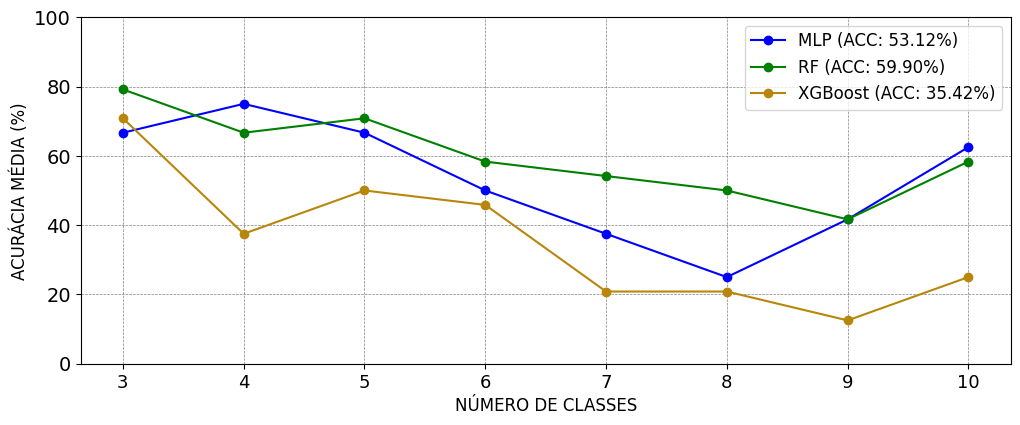

,MLP,RF,XGBoost
CLASSES,,,
3,0.5,0.513889,0.513889
4,0.5,0.458333,0.361111
5,0.416667,0.458333,0.361111
6,0.430556,0.319444,0.305556
7,0.194444,0.263889,0.208333
8,0.194444,0.291667,0.166667
9,0.180556,0.25,0.166667
10,0.361111,0.319444,0.152778


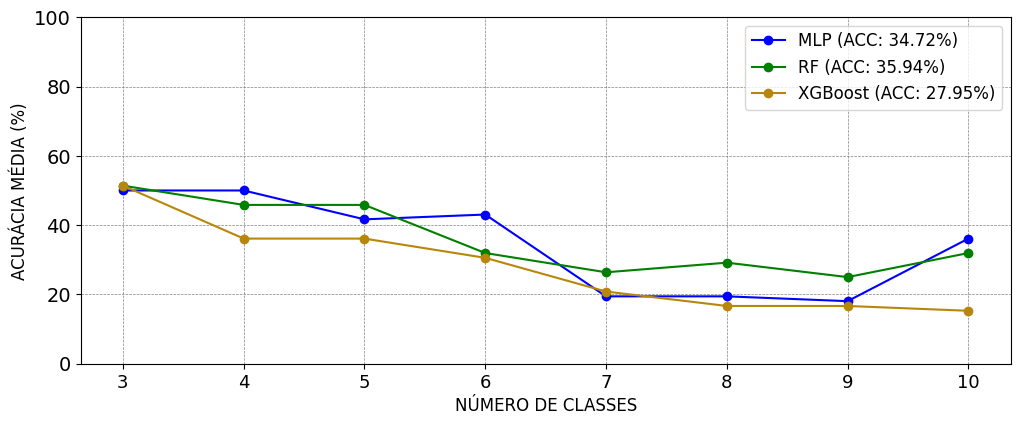

,MLP,RF,XGBoost
CLASSES,,,
3,0.423611,0.472222,0.388889
4,0.3125,0.333333,0.326389
5,0.298611,0.347222,0.291667
6,0.243056,0.215278,0.25
7,0.166667,0.208333,0.159722
8,0.138889,0.152778,0.201389
9,0.118056,0.166667,0.166667
10,0.1875,0.1875,0.131944


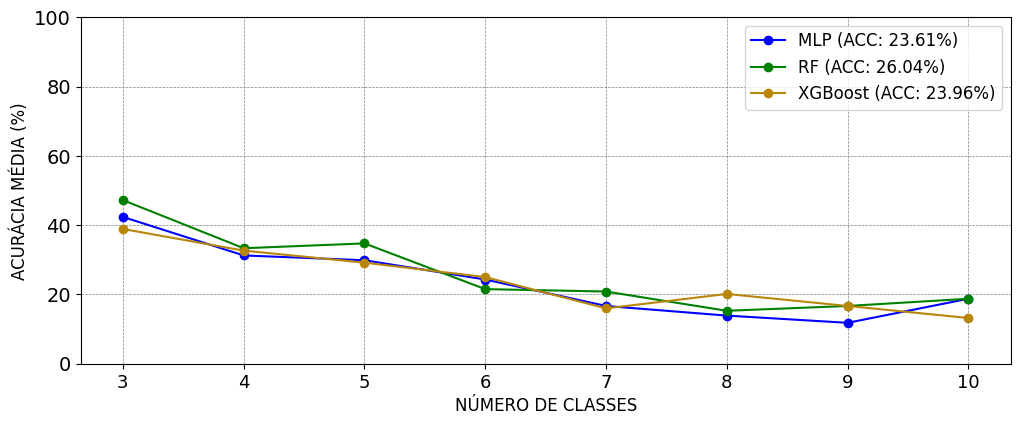

,MLP,RF,XGBoost
CLASSES,,,
3,0.510417,0.496528,0.496528
4,0.368056,0.371528,0.364583
5,0.322917,0.270833,0.319444
6,0.263889,0.229167,0.239583
7,0.211806,0.118056,0.211806
8,0.190972,0.072917,0.204861
9,0.107639,0.090278,0.142361
10,0.107639,0.072917,0.128472


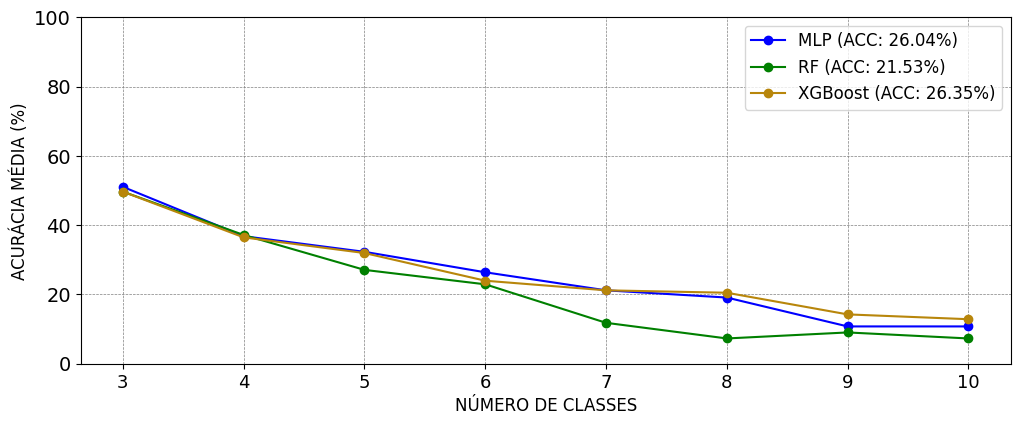

In [62]:
for horizonte in HORIZONTES:
    df_acc_todos = pd.DataFrame(columns=MODELOS, index=pd.Index(N_CLASSES, name="CLASSES"))
    for classes in N_CLASSES:
        df_real = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas.csv", sep=';',
                              decimal='.')

        df_acc = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())
        acc_classes = []

        for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
            try:
                consumo_previsto = pd.read_csv(
                    f"resultados/classificação - local/{classes} classes/{horizonte} meses/PREVISÕES CLASSIFICAÇÃO - LOCAL {horizonte}M - {campus}.csv",
                    sep=";", decimal=".", header=0)
            except Exception as e:
                continue

            consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
            consumo_previsto = consumo_previsto.set_index("DATA")

            dados["DATA"] = pd.to_datetime(dados["DATA"])
            dados = dados.set_index("DATA")

            df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
            df_acc.loc[campus] = df_desempenho["ACC"]
            acc_classes.append(df_desempenho["ACC"])

            df_desempenho.to_csv(f"resultados/classificação - local/{classes} classes/{horizonte} meses/ACURÁCIA CLASSIFICAÇÃO - LOCAL {horizonte}M {campus}.csv",
                                 sep=";", decimal=".", index=True)

        # Calcula as medidas de desempenho
        media_ACC = df_acc.mean()
        pior_ACC = (df_acc.eq(df_acc.min(axis=1), axis=0).sum(axis=0))
        melhor_ACC = (df_acc.eq(df_acc.max(axis=1), axis=0).sum(axis=0))

        df_acc.loc["MELHOR DESEMPENHO"] = melhor_ACC
        df_acc.loc["PIOR DESEMPENHO"] = pior_ACC
        df_acc.loc["SCORE DESEMPENHO (MELHOR - PIOR)"] = melhor_ACC - pior_ACC
        df_acc.loc["MÉDIA ACC"] = media_ACC

        # Atualiza o DataFrame global com a média de acurácia para o número de classes atual
        if acc_classes:
            df_acc_todos.loc[classes] = pd.concat(acc_classes, axis=1).mean(axis=1)

    display(df_acc_todos)
    df_acc_todos.to_csv(f"resultados/classificação - local/DESEMPENHO MÉDIO CLASSIFICAÇÃO - LOCAL {horizonte}M.csv", sep=";", decimal=".", index=True)
    plt = ts_comparacao_classes(df_acc_todos)
    plt.savefig(f"resultados/classificação - local/DESEMPENHO MÉDIO CLASSIFICAÇÃO - LOCAL {horizonte}M.png", bbox_inches='tight')
    plt.show()



### Evolução da Acurácia em relação ao Horizonte de Previsões


,MLP,RF,XGBoost
HORIZONTES,,,
1,0.666667,0.791667,0.708333
3,0.5,0.513889,0.513889
6,0.423611,0.472222,0.388889
12,0.510417,0.496528,0.496528


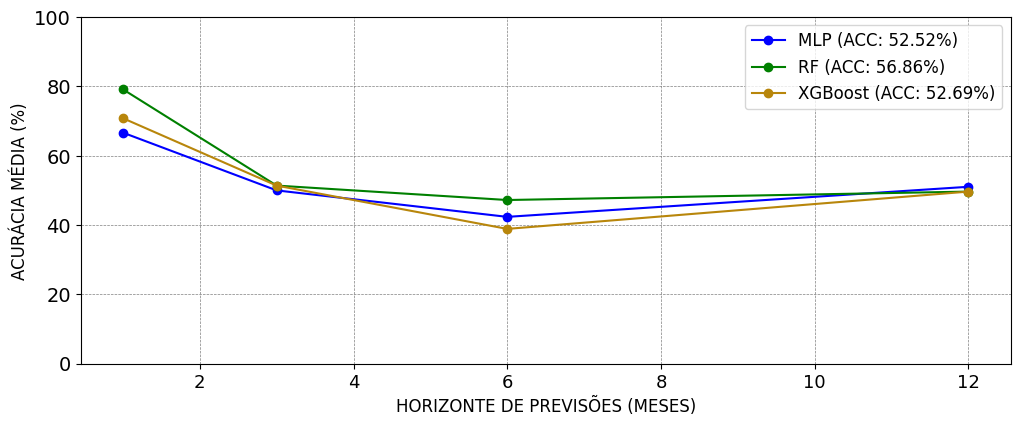

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.75,0.666667,0.375
3,0.5,0.458333,0.361111
6,0.3125,0.333333,0.326389
12,0.368056,0.371528,0.364583


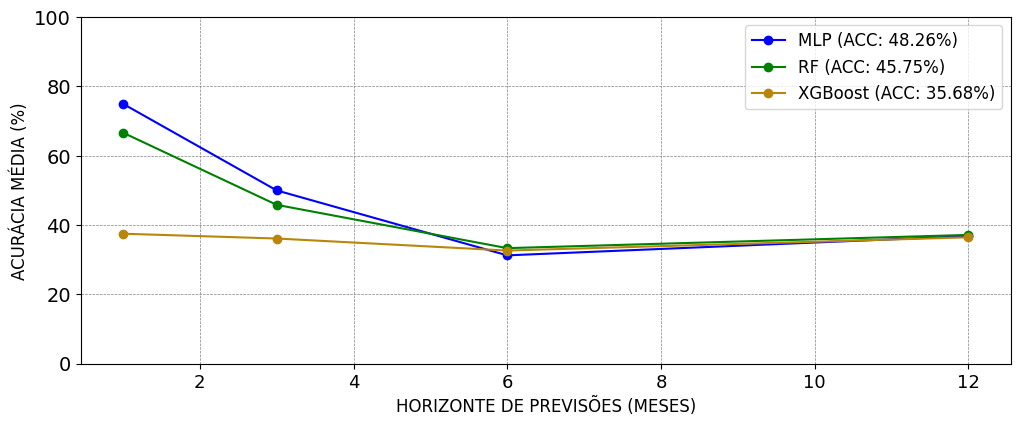

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.666667,0.708333,0.5
3,0.416667,0.458333,0.361111
6,0.298611,0.347222,0.291667
12,0.322917,0.270833,0.319444


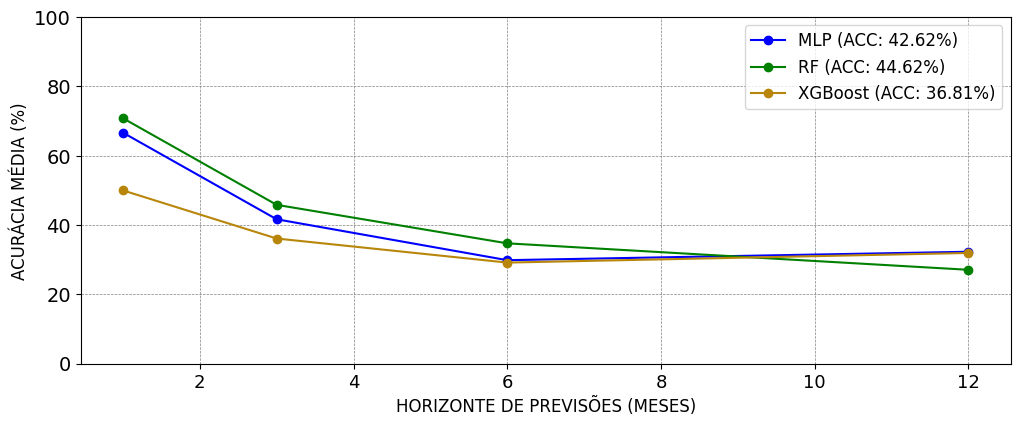

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.5,0.583333,0.458333
3,0.430556,0.319444,0.305556
6,0.243056,0.215278,0.25
12,0.263889,0.229167,0.239583


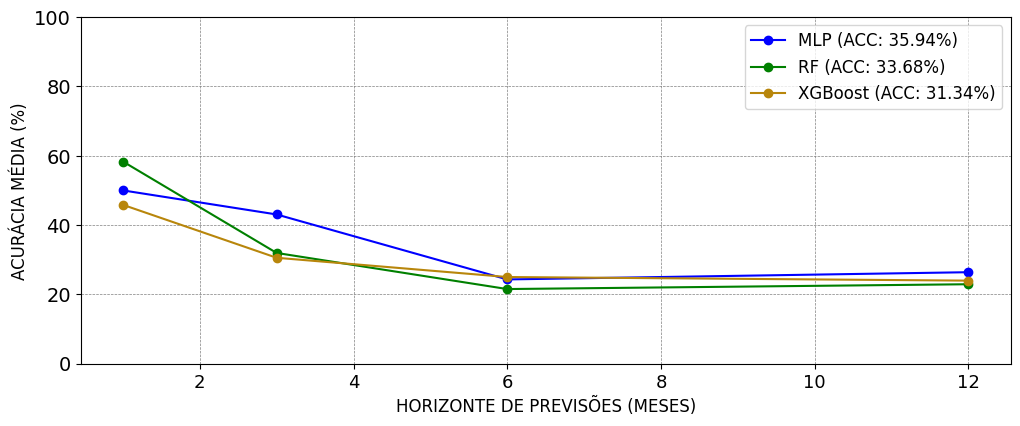

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.375,0.541667,0.208333
3,0.194444,0.263889,0.208333
6,0.166667,0.208333,0.159722
12,0.211806,0.118056,0.211806


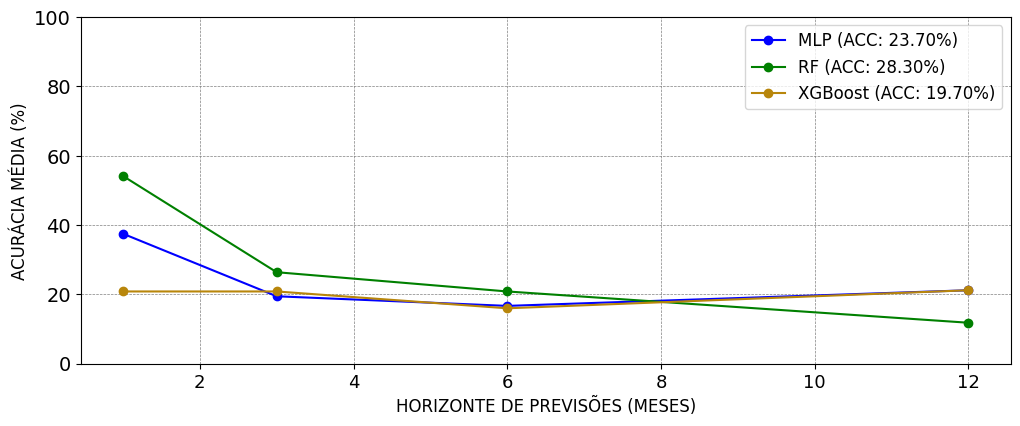

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.25,0.5,0.208333
3,0.194444,0.291667,0.166667
6,0.138889,0.152778,0.201389
12,0.190972,0.072917,0.204861


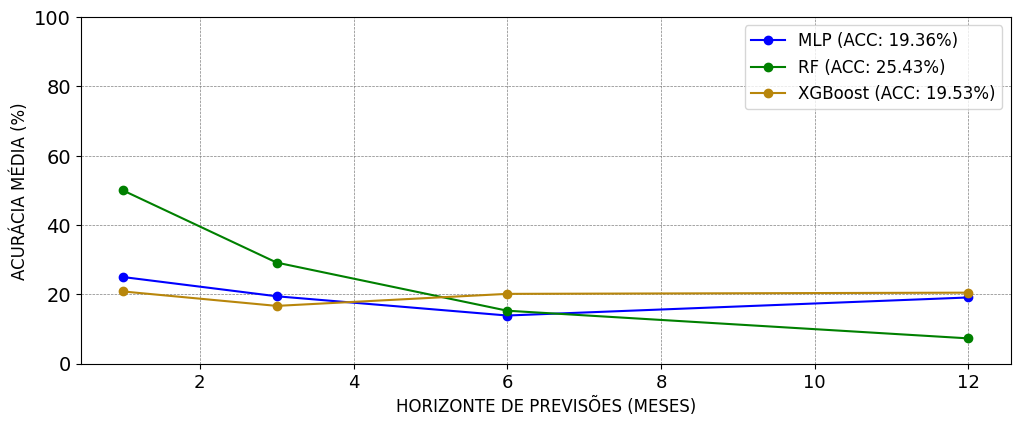

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.416667,0.416667,0.125
3,0.180556,0.25,0.166667
6,0.118056,0.166667,0.166667
12,0.107639,0.090278,0.142361


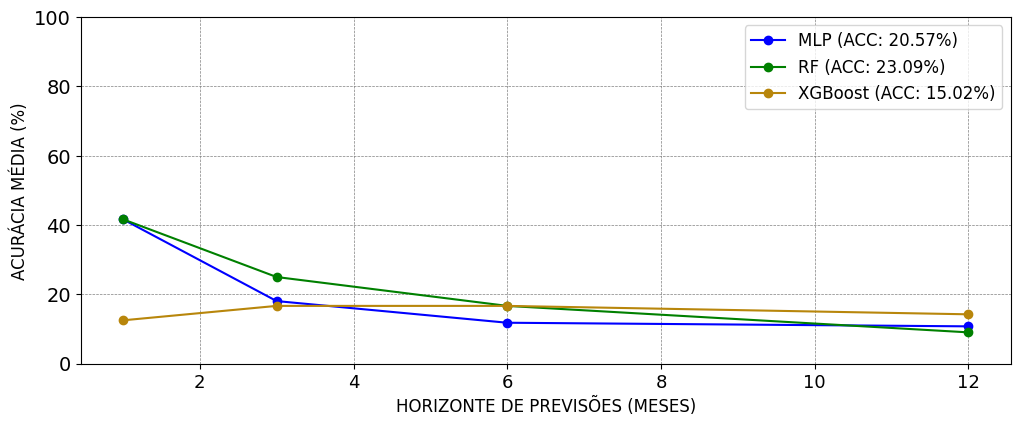

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.625,0.583333,0.25
3,0.361111,0.319444,0.152778
6,0.1875,0.1875,0.131944
12,0.107639,0.072917,0.128472


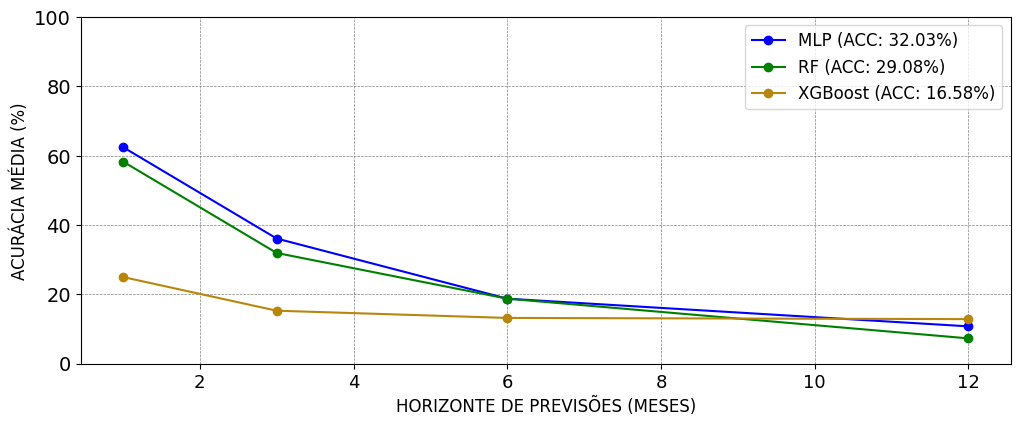

In [63]:
for classes in N_CLASSES:
    df_acc_todos = pd.DataFrame(columns=MODELOS, index=pd.Index(HORIZONTES, name="HORIZONTES"))
    df_real = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas.csv", sep=';',
                              decimal='.')
    for horizonte in HORIZONTES:
        df_acc = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())
        acc_horizontes = []

        for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
            try:
                consumo_previsto = pd.read_csv(
                    f"resultados/classificação - local/{classes} classes/{horizonte} meses/PREVISÕES CLASSIFICAÇÃO - LOCAL {horizonte}M - {campus}.csv",
                    sep=";", decimal=".", header=0)
            except Exception as e:
                continue

            consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
            consumo_previsto = consumo_previsto.set_index("DATA")

            dados["DATA"] = pd.to_datetime(dados["DATA"])
            dados = dados.set_index("DATA")

            df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
            df_acc.loc[campus] = df_desempenho["ACC"]
            acc_horizontes.append(df_desempenho["ACC"])

        # Calcula as medidas de desempenho
        media_ACC = df_acc.mean()
        pior_ACC = (df_acc.eq(df_acc.min(axis=1), axis=0).sum(axis=0))
        melhor_ACC = (df_acc.eq(df_acc.max(axis=1), axis=0).sum(axis=0))

        if acc_horizontes:
            df_acc_todos.loc[horizonte] = pd.concat(acc_horizontes, axis=1).mean(axis=1)

    display(df_acc_todos)
    plt = ts_comparacao_horizonte(df_acc_todos)
    plt.savefig(f"resultados/classificação - local/DESEMPENHO MÉDIO CLASSIFICAÇÃO - LOCAL {classes} CLASSES.png", bbox_inches='tight')
    plt.show()

## Treinamento Global

### Evolução da Acurácia em relação ao número de classes

,MLP,RF,XGBoost
CLASSES,,,
3,0.791667,0.916667,0.833333
4,0.708333,0.666667,0.625
5,0.75,0.791667,0.708333
6,0.625,0.833333,0.541667
7,0.625,0.666667,0.666667
8,0.208333,0.625,0.666667
9,0.5,0.416667,0.291667
10,0.666667,0.583333,0.458333


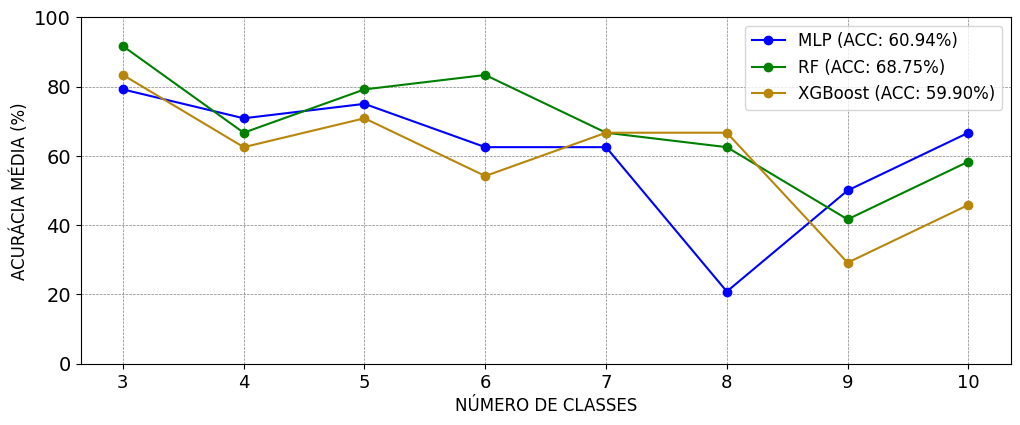

,MLP,RF,XGBoost
CLASSES,,,
3,0.652778,0.736111,0.680556
4,0.638889,0.611111,0.5
5,0.513889,0.541667,0.527778
6,0.305556,0.555556,0.5
7,0.291667,0.333333,0.430556
8,0.236111,0.402778,0.472222
9,0.25,0.347222,0.388889
10,0.263889,0.277778,0.208333


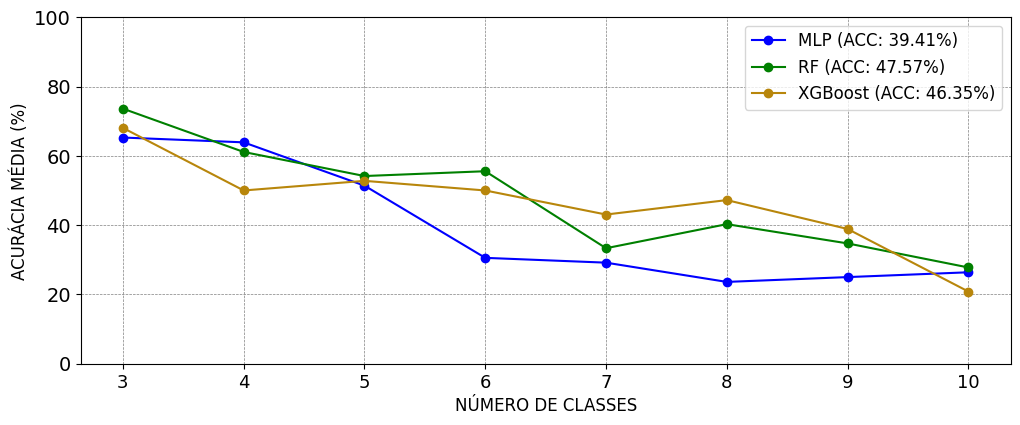

,MLP,RF,XGBoost
CLASSES,,,
3,0.472222,0.527778,0.5625
4,0.451389,0.430556,0.368056
5,0.423611,0.375,0.4375
6,0.3125,0.340278,0.305556
7,0.222222,0.3125,0.277778
8,0.166667,0.25,0.298611
9,0.118056,0.208333,0.25
10,0.145833,0.201389,0.215278


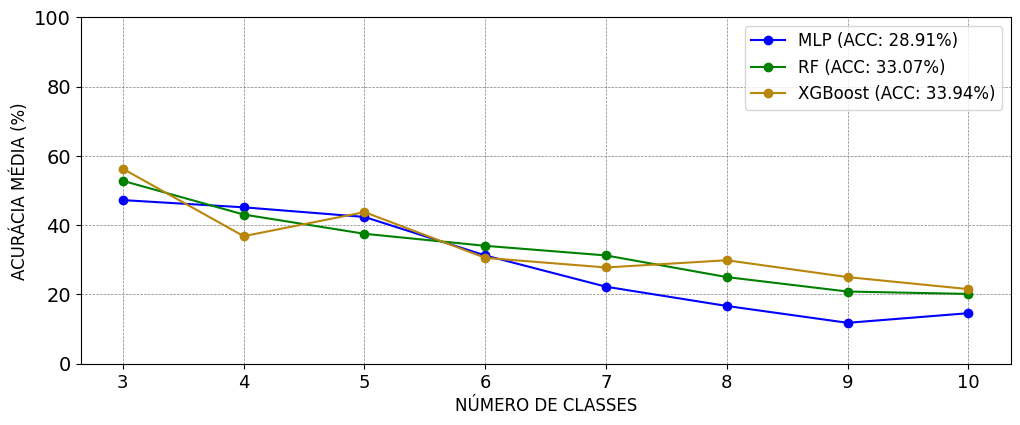

,MLP,RF,XGBoost
CLASSES,,,
3,0.576389,0.590278,0.604167
4,0.489583,0.513889,0.447917
5,0.25,0.479167,0.46875
6,0.430556,0.375,0.399306
7,0.267361,0.340278,0.298611
8,0.267361,0.277778,0.333333
9,0.170139,0.208333,0.246528
10,0.204861,0.1875,0.25


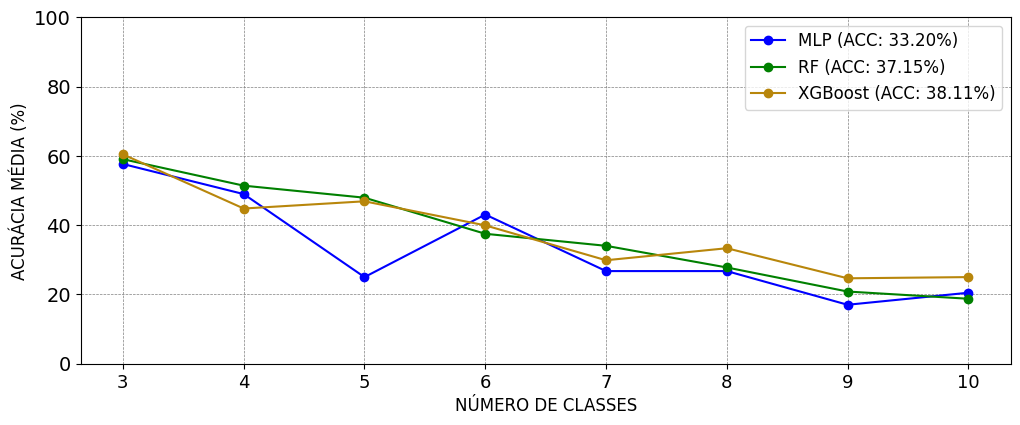

In [64]:
for horizonte in HORIZONTES:
    df_acc_todos = pd.DataFrame(columns=MODELOS, index=pd.Index(N_CLASSES, name="CLASSES"))
    for classes in N_CLASSES:
        df_real = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas.csv", sep=';',
                              decimal='.')

        df_acc = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())
        acc_classes = []

        for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
            try:
                consumo_previsto = pd.read_csv(
                    f"resultados/classificação - global/{classes} classes/{horizonte} meses/PREVISÕES CLASSIFICAÇÃO - GLOBAL {horizonte}M - {campus}.csv",
                    sep=";", decimal=".", header=0)
            except Exception as e:
                continue

            consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
            consumo_previsto = consumo_previsto.set_index("DATA")

            dados["DATA"] = pd.to_datetime(dados["DATA"])
            dados = dados.set_index("DATA")

            df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
            df_acc.loc[campus] = df_desempenho["ACC"]
            acc_classes.append(df_desempenho["ACC"])

            df_desempenho.to_csv(f"resultados/classificação - global/{classes} classes/{horizonte} meses/ACURÁCIA CLASSIFICAÇÃO - GLOBAL {horizonte}M {campus}.csv",
                                 sep=";", decimal=".", index=True)

        # Calcula as medidas de desempenho
        media_ACC = df_acc.mean()
        pior_ACC = (df_acc.eq(df_acc.min(axis=1), axis=0).sum(axis=0))
        melhor_ACC = (df_acc.eq(df_acc.max(axis=1), axis=0).sum(axis=0))

        df_acc.loc["MELHOR DESEMPENHO"] = melhor_ACC
        df_acc.loc["PIOR DESEMPENHO"] = pior_ACC
        df_acc.loc["SCORE DESEMPENHO (MELHOR - PIOR)"] = melhor_ACC - pior_ACC
        df_acc.loc["MÉDIA ACC"] = media_ACC

        if acc_classes:
            df_acc_todos.loc[classes] = pd.concat(acc_classes, axis=1).mean(axis=1)

    # Exibe o gráfico com as médias globais
    display(df_acc_todos)
    df_acc_todos.to_csv(f"resultados/classificação - global/DESEMPENHO MÉDIO CLASSIFICAÇÃO - GLOBAL {horizonte}M.csv", sep=";", decimal=".", index=True)
    plt = ts_comparacao_classes(df_acc_todos)
    plt.savefig(f"resultados/classificação - global/DESEMPENHO MÉDIO CLASSIFICAÇÃO - GLOBAL {horizonte}M.png", bbox_inches='tight')
    plt.show()



### Evolução da Acurácia em relação ao Horizonte de Previsões


,MLP,RF,XGBoost
HORIZONTES,,,
1,0.791667,0.916667,0.833333
3,0.652778,0.736111,0.680556
6,0.472222,0.527778,0.5625
12,0.576389,0.590278,0.604167


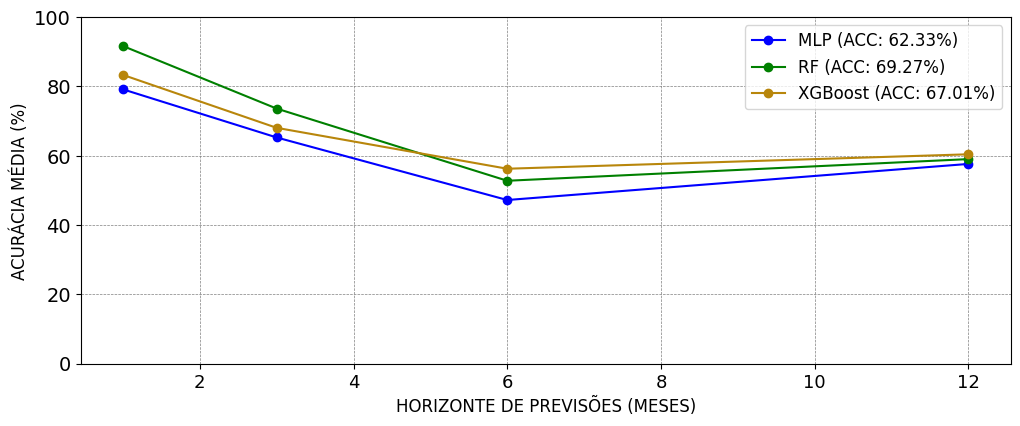

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.708333,0.666667,0.625
3,0.638889,0.611111,0.5
6,0.451389,0.430556,0.368056
12,0.489583,0.513889,0.447917


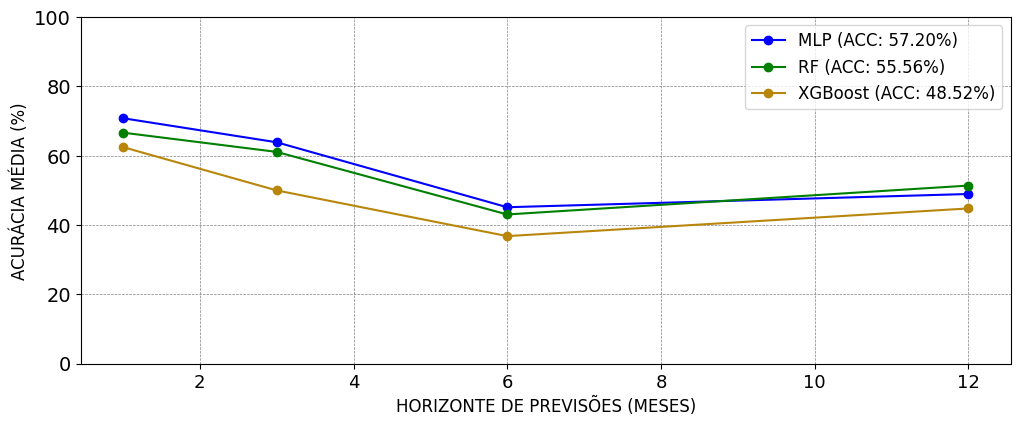

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.75,0.791667,0.708333
3,0.513889,0.541667,0.527778
6,0.423611,0.375,0.4375
12,0.25,0.479167,0.46875


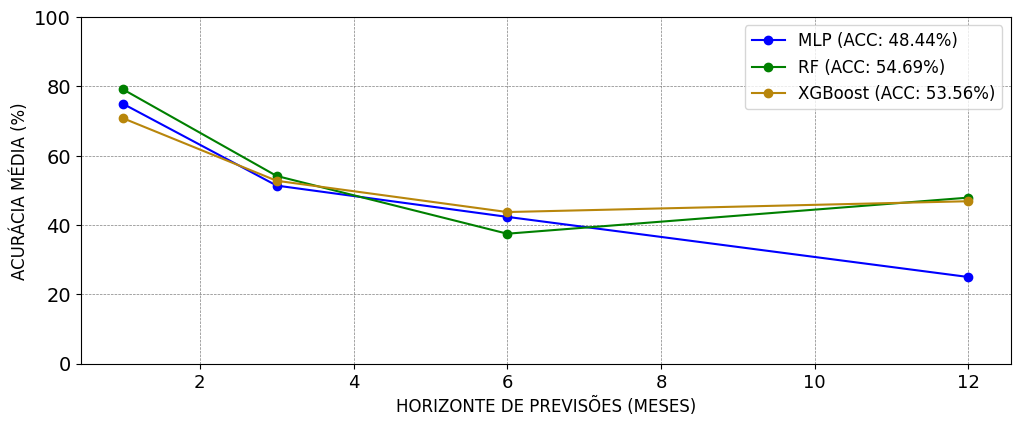

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.625,0.833333,0.541667
3,0.305556,0.555556,0.5
6,0.3125,0.340278,0.305556
12,0.430556,0.375,0.399306


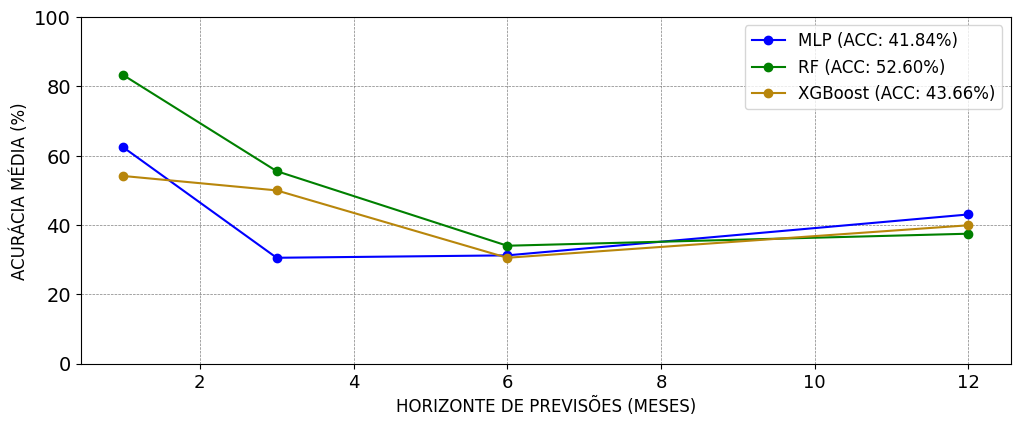

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.625,0.666667,0.666667
3,0.291667,0.333333,0.430556
6,0.222222,0.3125,0.277778
12,0.267361,0.340278,0.298611


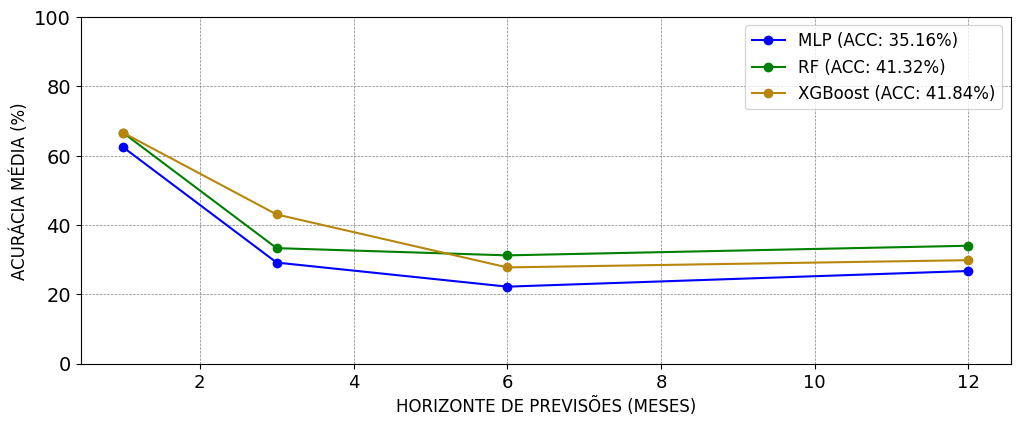

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.208333,0.625,0.666667
3,0.236111,0.402778,0.472222
6,0.166667,0.25,0.298611
12,0.267361,0.277778,0.333333


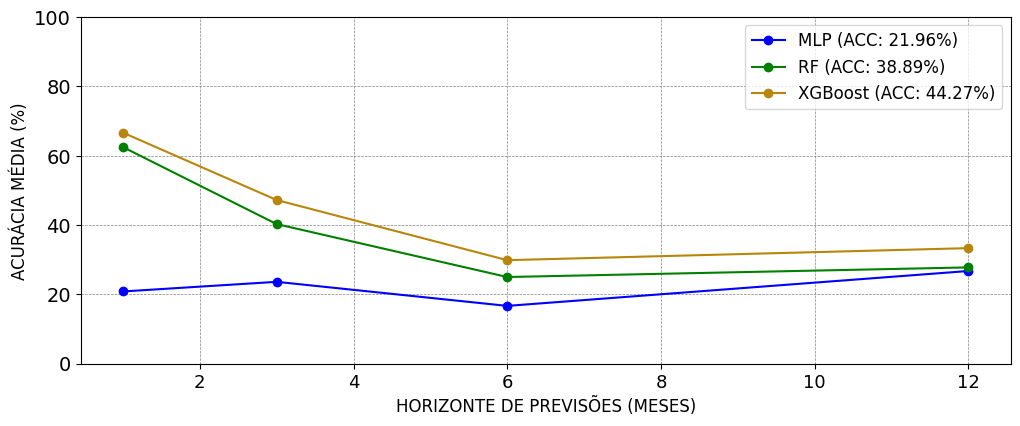

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.5,0.416667,0.291667
3,0.25,0.347222,0.388889
6,0.118056,0.208333,0.25
12,0.170139,0.208333,0.246528


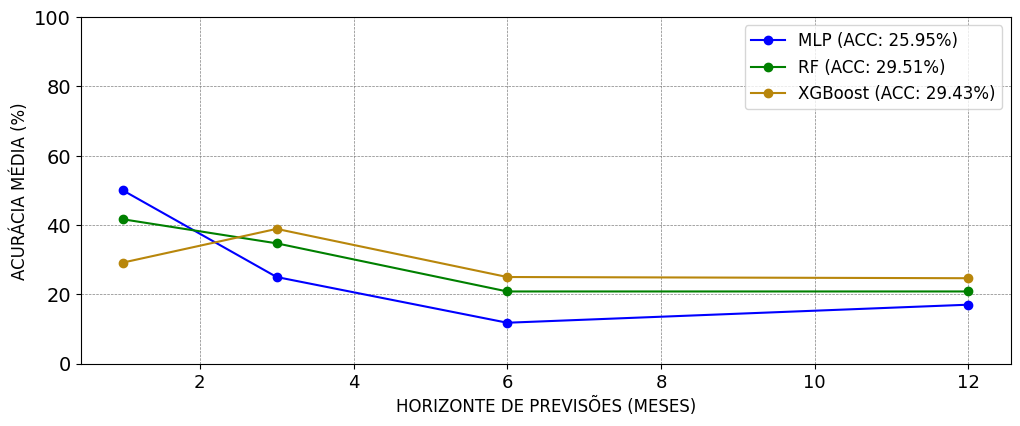

,MLP,RF,XGBoost
HORIZONTES,,,
1,0.666667,0.583333,0.458333
3,0.263889,0.277778,0.208333
6,0.145833,0.201389,0.215278
12,0.204861,0.1875,0.25


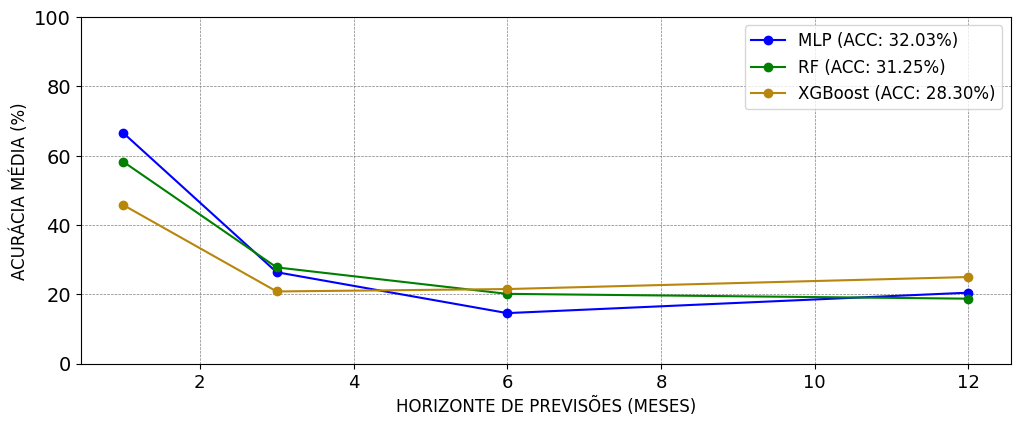

In [65]:
for classes in N_CLASSES:
    df_acc_todos = pd.DataFrame(columns=MODELOS, index=pd.Index(HORIZONTES, name="HORIZONTES"))
    df_real = pd.read_csv(f"./dados/classes/{classes} classes/{classes}_classes_normalizadas.csv", sep=';',
                              decimal='.')
    for horizonte in HORIZONTES:
        df_acc = pd.DataFrame(columns=MODELOS, index=df_real["CAMPUS"].unique())
        acc_horizontes = []

        for campus, dados in df_real.sort_values("DATA").groupby("CAMPUS"):
            try:
                consumo_previsto = pd.read_csv(
                    f"resultados/classificação - global/{classes} classes/{horizonte} meses/PREVISÕES CLASSIFICAÇÃO - GLOBAL {horizonte}M - {campus}.csv",
                    sep=";", decimal=".", header=0)
            except Exception as e:
                continue

            consumo_previsto["DATA"] = pd.to_datetime(consumo_previsto["DATA"])
            consumo_previsto = consumo_previsto.set_index("DATA")

            dados["DATA"] = pd.to_datetime(dados["DATA"])
            dados = dados.set_index("DATA")

            df_desempenho = medidas_desempenho(dados, consumo_previsto, horizonte)
            df_acc.loc[campus] = df_desempenho["ACC"]
            acc_horizontes.append(df_desempenho["ACC"])

        # Calcula as medidas de desempenho
        media_ACC = df_acc.mean()
        pior_ACC = (df_acc.eq(df_acc.min(axis=1), axis=0).sum(axis=0))
        melhor_ACC = (df_acc.eq(df_acc.max(axis=1), axis=0).sum(axis=0))

        if acc_horizontes:
            df_acc_todos.loc[horizonte] = pd.concat(acc_horizontes, axis=1).mean(axis=1)

    display(df_acc_todos)
    plt = ts_comparacao_horizonte(df_acc_todos)
    plt.savefig(f"resultados/classificação - global/DESEMPENHO MÉDIO CLASSIFICAÇÃO - GLOBAL {classes} CLASSES.png", bbox_inches='tight')
    plt.show()